In [2]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")

connection.authenticate_oidc()

print("Conexión realizada correctamente")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=VQCZ-EKXE 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Conexión realizada correctamente


In [3]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

Guardar fechas

In [4]:
fechas_atitlan = [
    "2025-01-18",
    "2025-04-13",
    "2025-05-13",
    "2025-07-17",
    "2025-11-21",
    "2025-12-29",
    "2026-02-12",
    "2026-03-24",
    "2026-04-13",
    "2026-04-28",
    "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28",
    "2025-04-15",
    "2025-04-28",
    "2025-11-24",
    "2026-01-08",
    "2026-02-02",
    "2026-02-07",
    "2026-03-29",
    "2026-04-13",
    "2026-04-28",
    "2026-06-19"
]

print("Fechas Atitlán:", len(fechas_atitlan))
print("Fechas Amatitlán:", len(fechas_amatitlan))

Fechas Atitlán: 11
Fechas Amatitlán: 11


In [5]:
collections = connection.list_collection_ids()

[x for x in collections if "SENTINEL" in x.upper()]

['SENTINEL1_GRD',
 'SENTINEL3_OLCI_L1B',
 'SENTINEL3_SLSTR',
 'SENTINEL_5P_L2',
 'SENTINEL3_SYN_L2_SYN',
 'SENTINEL3_SLSTR_L2_LST',
 'SENTINEL1_GLOBAL_MOSAICS',
 'SENTINEL2_L2A',
 'SENTINEL2_L1C',
 'SENTINEL3_OLCI_L2_LAND',
 'SENTINEL3_OLCI_L2_WATER',
 'SENTINEL3_SYN_L2_AOD']

Pruebas de informacion

In [6]:
atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=lago_atitlan,
    temporal_extent=["2025-01-18", "2026-07-22"],
    bands=["B03", "B04", "B08"]
)

print(atitlan_cube)

DataCube(<PGNode 'load_collection' at 0x207b29ff7f0>)


In [7]:
amatitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=lago_amatitlan,
    temporal_extent=["2025-01-28", "2026-06-19"],
    bands=["B03", "B04", "B08"]
)

print(amatitlan_cube)

DataCube(<PGNode 'load_collection' at 0x207b29ffb60>)


Descargar solamente los datos solicitados por fechas

In [18]:
from datetime import datetime, timedelta

def cargar_fecha(lago, fecha):
    """
    Carga únicamente B03, B04 y B08 de Sentinel-2 L2A
    para una fecha específica y un lago.
    """
    
    inicio = datetime.strptime(fecha, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)

    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=lago,
        temporal_extent=[
            inicio.strftime("%Y-%m-%d"),
            fin.strftime("%Y-%m-%d")
        ],
        bands=["B03", "B04", "B08"]
    )
    
    return cube

In [20]:
prueba_atitlan = cargar_fecha(
    lago_atitlan,
    "2025-01-18"
)

print(prueba_atitlan)

DataCube(<PGNode 'load_collection' at 0x207b29ff200>)


In [21]:
def calcular_indices(cube):
    # Seleccionar bandas
    B03 = cube.band("B03")
    B04 = cube.band("B04")
    B08 = cube.band("B08")

    # NDVI = (B08 - B04) / (B08 + B04)
    ndvi = (B08 - B04) / (B08 + B04)

    # NDWI = (B03 - B08) / (B03 + B08)
    ndwi = (B03 - B08) / (B03 + B08)

    return ndvi, ndwi

In [22]:
ndvi_prueba, ndwi_prueba = calcular_indices(prueba_atitlan)

print("NDVI:")
print(ndvi_prueba)

print("\nNDWI:")
print(ndwi_prueba)

NDVI:
DataCube(<ReduceNode 'reduce_dimension' at 0x207b2a6e8f0>)

NDWI:
DataCube(<ReduceNode 'reduce_dimension' at 0x207b2a6ea30>)


In [23]:
def cargar_fecha_cyano(lago, fecha):
    """
    Carga las bandas utilizadas por el CyanoLakes Script
    para una fecha específica.
    """

    inicio = datetime.strptime(fecha, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)

    cube = connection.load_collection(
        "SENTINEL2_L1C",
        spatial_extent=lago,
        temporal_extent=[
            inicio.strftime("%Y-%m-%d"),
            fin.strftime("%Y-%m-%d")
        ],
        bands=[
            "B02",
            "B03",
            "B04",
            "B05",
            "B07",
            "B08",
            "B8A",
            "B11",
            "B12"
        ]
    )

    return cube

In [24]:
cyano_prueba = cargar_fecha_cyano(
    lago_atitlan,
    "2025-01-18"
)

print(cyano_prueba)

DataCube(<PGNode 'load_collection' at 0x207b2aa6530>)


In [25]:
def calcular_cyano(cube):
    # Bandas utilizadas para NDCI
    B04 = cube.band("B04")
    B05 = cube.band("B05")

    # NDCI
    ndci = (B05 - B04) / (B05 + B04)

    # Estimación de clorofila-a del CyanoLakes Script
    chl = (
        826.57 * (ndci ** 3)
        - 176.43 * (ndci ** 2)
        + 19 * ndci
        + 4.071
    )

    return chl

In [26]:
chl_prueba = calcular_cyano(cyano_prueba)

print(chl_prueba)

DataCube(<ReduceNode 'reduce_dimension' at 0x207b2a6f340>)


In [27]:
def crear_mascara_agua(cube):
    """
    Crea una máscara de agua siguiendo las condiciones
    utilizadas por el CyanoLakes Script.
    """

    # Bandas
    B02 = cube.band("B02")
    B03 = cube.band("B03")
    B04 = cube.band("B04")
    B08 = cube.band("B08")
    B11 = cube.band("B11")
    B12 = cube.band("B12")

    # Índices utilizados para detectar agua
    ndvi = (B08 - B04) / (B08 + B04)

    mndwi = (B03 - B11) / (B03 + B11)

    ndwi = (B03 - B08) / (B03 + B08)

    ndwi_leaves = (B08 - B11) / (B08 + B11)

    aweish = (
        B02
        + 2.5 * B03
        - 1.5 * (B08 + B11)
        - 0.25 * B12
    )

    aweinsh = (
        4 * (B03 - B11)
        - (0.25 * B08 + 2.75 * B11)
    )

    dbsi = (
        ((B11 - B03) / (B11 + B03))
        - ndvi
    )

    # Un píxel se considera posible agua si cumple
    # al menos una de estas condiciones
    water = (
        (mndwi > 0.42)
        | (ndwi > 0.4)
        | (aweinsh > 0.1879)
        | (aweish > 0.1112)
        | (ndvi < -0.2)
        | (ndwi_leaves > 1)
    )

    # Eliminar posibles áreas urbanas o suelo desnudo
    no_agua = (
        (aweinsh <= -0.03)
        | (dbsi > 0)
    )

    # Máscara definitiva
    water_final = water & (~no_agua)

    return water_final

In [28]:
mascara_agua_prueba = crear_mascara_agua(cyano_prueba)

print(mascara_agua_prueba)

DataCube(<ReduceNode 'reduce_dimension' at 0x207b2a99360>)


In [29]:
chl_agua_prueba = chl_prueba.mask(~mascara_agua_prueba)

print(chl_agua_prueba)

DataCube(<PGNode 'mask' at 0x207b2a6eee0>)


In [32]:
resultado = chl_agua_prueba.save_result(format="GTiff")

resultado.download("chl_atitlan_2025-01-18.tif")

In [36]:
import rasterio
import numpy as np

archivo = "chl_atitlan_2025-01-18.tif"

with rasterio.open(archivo) as src:
    datos = src.read(1).astype(float)
    nodata = src.nodata

    print("Tamaño:", datos.shape)
    print("NoData:", nodata)
    print("CRS:", src.crs)

# Convertir NoData a NaN, si el archivo tiene NoData definido
if nodata is not None:
    datos[datos == nodata] = np.nan

# Eliminar infinitos
datos[~np.isfinite(datos)] = np.nan

print("Píxeles válidos:", np.sum(~np.isnan(datos)))
print("Mínimo:", np.nanmin(datos))
print("Máximo:", np.nanmax(datos))
print("Promedio:", np.nanmean(datos))

promedio_cyano = np.nanmean(datos)

print(
    f"Promedio Atitlán - 2025-01-18: "
    f"{promedio_cyano:.4f}"
)

Tamaño: (1751, 2759)
NoData: nan
CRS: EPSG:32615
Píxeles válidos: 1245206
Mínimo: -270.5416259765625
Máximo: 30.66293716430664
Promedio: 0.41514202220393465
Promedio Atitlán - 2025-01-18: 0.4151


In [37]:
# Revisar la distribución de los valores obtenidos

validos = datos[np.isfinite(datos)]

print("Cantidad de píxeles:", len(validos))
print()
print("Percentiles:")
print("1%:  ", np.percentile(validos, 1))
print("5%:  ", np.percentile(validos, 5))
print("25%: ", np.percentile(validos, 25))
print("50%: ", np.percentile(validos, 50))
print("75%: ", np.percentile(validos, 75))
print("95%: ", np.percentile(validos, 95))
print("99%: ", np.percentile(validos, 99))

print()
print("Píxeles negativos:", np.sum(validos < 0))
print("Píxeles >= 0:", np.sum(validos >= 0))
print(
    "Porcentaje de valores negativos:",
    np.mean(validos < 0) * 100
)

Cantidad de píxeles: 1245206

Percentiles:
1%:   -2.6093497276306152
5%:   -1.55796480178833
25%:  -0.33795166015625
50%:  0.43181324005126953
75%:  1.1156425476074219
95%:  2.2659199237823486
99%:  4.475793361663818

Píxeles negativos: 434251
Píxeles >= 0: 810955
Porcentaje de valores negativos: 34.87382810555041


In [38]:
# Crear una copia para no modificar los datos originales
datos_limpios = datos.copy()

# Los valores negativos de concentración se llevan a 0
datos_limpios[datos_limpios < 0] = 0

# Calcular estadísticas
promedio_cyano = np.nanmean(datos_limpios)
mediana_cyano = np.nanmedian(datos_limpios)

print("Promedio corregido:", promedio_cyano)
print("Mediana:", mediana_cyano)
print("Mínimo:", np.nanmin(datos_limpios))
print("Máximo:", np.nanmax(datos_limpios))

Promedio corregido: 0.7109180944277926
Mediana: 0.43181324005126953
Mínimo: 0.0
Máximo: 30.66293716430664


FUNCION QUE DESCARGARA TODO

In [39]:
import os
import rasterio
import numpy as np

os.makedirs("resultados_cyano", exist_ok=True)


def procesar_fecha_cyano(lago, nombre_lago, fecha):
    print(f"\nProcesando {nombre_lago} - {fecha}")

    # 1. Cargar Sentinel-2 L1C
    cube = cargar_fecha_cyano(lago, fecha)

    # 2. Calcular chl
    chl = calcular_cyano(cube)

    # 3. Crear máscara de agua
    mascara_agua = crear_mascara_agua(cube)

    # 4. Aplicar máscara
    chl_agua = chl.mask(~mascara_agua)

    # 5. Nombre del archivo
    archivo = f"resultados_cyano/{nombre_lago}_{fecha}.tif"

    # 6. Descargar GeoTIFF
    resultado = chl_agua.save_result(format="GTiff")
    resultado.download(archivo)

    # 7. Leer TIFF
    with rasterio.open(archivo) as src:
        datos = src.read(1).astype(float)
        nodata = src.nodata

    # 8. Limpiar NoData e infinitos
    if nodata is not None and not np.isnan(nodata):
        datos[datos == nodata] = np.nan

    datos[~np.isfinite(datos)] = np.nan

    # 9. Concentraciones negativas -> 0
    datos[datos < 0] = 0

    # 10. Estadísticas
    promedio = np.nanmean(datos)
    mediana = np.nanmedian(datos)
    maximo = np.nanmax(datos)
    pixeles = np.sum(~np.isnan(datos))

    print(f"Promedio: {promedio:.4f}")
    print(f"Mediana: {mediana:.4f}")
    print(f"Máximo: {maximo:.4f}")
    print(f"Píxeles válidos: {pixeles}")

    return {
        "lago": nombre_lago,
        "fecha": fecha,
        "promedio_cyano": promedio,
        "mediana_cyano": mediana,
        "maximo_cyano": maximo,
        "pixeles_validos": pixeles
    }

In [40]:
prueba_automatica = procesar_fecha_cyano(
    lago_atitlan,
    "atitlan",
    "2025-04-13"
)

print(prueba_automatica)


Procesando atitlan - 2025-04-13
Promedio: 1.7919
Mediana: 1.7753
Máximo: 23.6735
Píxeles válidos: 1220349
{'lago': 'atitlan', 'fecha': '2025-04-13', 'promedio_cyano': np.float64(1.7919065408948087), 'mediana_cyano': np.float64(1.7752902507781982), 'maximo_cyano': np.float64(23.67352294921875), 'pixeles_validos': np.int64(1220349)}


In [41]:
resultados_atitlan = []

for fecha in fechas_atitlan:
    try:
        resultado = procesar_fecha_cyano(
            lago_atitlan,
            "atitlan",
            fecha
        )

        resultados_atitlan.append(resultado)

    except Exception as e:
        print(f"ERROR en Atitlán {fecha}")
        print(e)


Procesando atitlan - 2025-01-18
Promedio: 0.7109
Mediana: 0.4318
Máximo: 30.6629
Píxeles válidos: 1245206

Procesando atitlan - 2025-04-13
Promedio: 1.7919
Mediana: 1.7753
Máximo: 23.6735
Píxeles válidos: 1220349

Procesando atitlan - 2025-05-13
Promedio: 1.3538
Mediana: 1.3081
Máximo: 17.6163
Píxeles válidos: 1220129

Procesando atitlan - 2025-07-17
Promedio: 1.2840
Mediana: 1.2031
Máximo: 139.2647
Píxeles válidos: 1194184

Procesando atitlan - 2025-11-21
Promedio: 0.6487
Mediana: 0.3293
Máximo: 83.2214
Píxeles válidos: 1230222

Procesando atitlan - 2025-12-29
Promedio: 0.7883
Mediana: 0.5525
Máximo: 28.2775
Píxeles válidos: 1249529

Procesando atitlan - 2026-02-12
Promedio: 1.0066
Mediana: 0.9300
Máximo: 27.2515
Píxeles válidos: 1227907

Procesando atitlan - 2026-03-24
Promedio: 1.3004
Mediana: 1.2789
Máximo: 14.1745
Píxeles válidos: 1222517

Procesando atitlan - 2026-04-13
Promedio: 2.1501
Mediana: 2.2227
Máximo: 22.9222
Píxeles válidos: 1217818

Procesando atitlan - 2026-04-28
Pro

In [42]:
import pandas as pd

df_atitlan = pd.DataFrame(resultados_atitlan)

df_atitlan

,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,atitlan,2025-01-18,0.710918,0.431813,30.662937,1245206
1,atitlan,2025-04-13,1.791907,1.775290,23.673523,1220349
2,atitlan,2025-05-13,1.353840,1.308052,17.616255,1220129
3,atitlan,2025-07-17,1.283958,1.203052,139.264664,1194184
4,atitlan,2025-11-21,0.648743,0.329348,83.221436,1230222
5,atitlan,2025-12-29,0.788283,0.552496,28.277519,1249529
6,atitlan,2026-02-12,1.006557,0.929990,27.251480,1227907
7,atitlan,2026-03-24,1.300402,1.278947,14.174520,1222517
8,atitlan,2026-04-13,2.150134,2.222661,22.922173,1217818
9,atitlan,2026-04-28,1.868356,1.896074,14.942901,1217073


In [43]:
print("Fechas procesadas:", len(df_atitlan))

Fechas procesadas: 11


In [44]:
df_atitlan.to_csv(
    "resultados_cyano_atitlan.csv",
    index=False
)

In [45]:
resultados_amatitlan = []

for fecha in fechas_amatitlan:
    try:
        resultado = procesar_fecha_cyano(
            lago_amatitlan,
            "amatitlan",
            fecha
        )

        resultados_amatitlan.append(resultado)

    except Exception as e:
        print(f"ERROR en Amatitlán {fecha}")
        print(e)


Procesando amatitlan - 2025-01-28
Promedio: 4.4292
Mediana: 4.4891
Máximo: 22.3546
Píxeles válidos: 147442

Procesando amatitlan - 2025-04-15
Promedio: 4.5370
Mediana: 4.5757
Máximo: 27.1121
Píxeles válidos: 144535

Procesando amatitlan - 2025-04-28
Promedio: 5.7731
Mediana: 4.8691
Máximo: 42.7746
Píxeles válidos: 144731

Procesando amatitlan - 2025-11-24
Promedio: 4.7315
Mediana: 4.0388
Máximo: 126.0842
Píxeles válidos: 147330

Procesando amatitlan - 2026-01-08
Promedio: 6.8169
Mediana: 4.8918
Máximo: 137.7701
Píxeles válidos: 148399

Procesando amatitlan - 2026-02-02
Promedio: 4.2909
Mediana: 4.3950
Máximo: 19.1408
Píxeles válidos: 145496

Procesando amatitlan - 2026-02-07
Promedio: 4.3065
Mediana: 4.4495
Máximo: 17.5996
Píxeles válidos: 146746

Procesando amatitlan - 2026-03-29
Promedio: 6.4357
Mediana: 5.2404
Máximo: 58.3989
Píxeles válidos: 146463

Procesando amatitlan - 2026-04-13
Promedio: 6.7362
Mediana: 6.3982
Máximo: 45.3467
Píxeles válidos: 147301

Procesando amatitlan - 20

In [46]:
df_amatitlan = pd.DataFrame(resultados_amatitlan)

df_amatitlan

,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,amatitlan,2025-01-28,4.429233,4.489111,22.354576,147442
1,amatitlan,2025-04-15,4.536978,4.575728,27.112144,144535
2,amatitlan,2025-04-28,5.773149,4.869077,42.774620,144731
3,amatitlan,2025-11-24,4.731506,4.038785,126.084167,147330
4,amatitlan,2026-01-08,6.816948,4.891778,137.770126,148399
5,amatitlan,2026-02-02,4.290862,4.394993,19.140800,145496
6,amatitlan,2026-02-07,4.306512,4.449463,17.599585,146746
7,amatitlan,2026-03-29,6.435742,5.240434,58.398903,146463
8,amatitlan,2026-04-13,6.736215,6.398186,45.346699,147301
9,amatitlan,2026-04-28,10.030859,6.467231,50.366486,141031


In [47]:
print("Fechas procesadas:", len(df_amatitlan))

Fechas procesadas: 11


In [48]:
df_amatitlan.to_csv(
    "resultados_cyano_amatitlan.csv",
    index=False
)

Unir resultados

In [49]:
df_resultados = pd.concat(
    [df_atitlan, df_amatitlan],
    ignore_index=True
)

# Convertir fecha a formato datetime
df_resultados["fecha"] = pd.to_datetime(df_resultados["fecha"])

# Ordenar
df_resultados = df_resultados.sort_values(
    ["lago", "fecha"]
).reset_index(drop=True)

df_resultados

,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,amatitlan,2025-01-28,4.429233,4.489111,22.354576,147442
1,amatitlan,2025-04-15,4.536978,4.575728,27.112144,144535
2,amatitlan,2025-04-28,5.773149,4.869077,42.774620,144731
3,amatitlan,2025-11-24,4.731506,4.038785,126.084167,147330
4,amatitlan,2026-01-08,6.816948,4.891778,137.770126,148399
5,amatitlan,2026-02-02,4.290862,4.394993,19.140800,145496
6,amatitlan,2026-02-07,4.306512,4.449463,17.599585,146746
7,amatitlan,2026-03-29,6.435742,5.240434,58.398903,146463
8,amatitlan,2026-04-13,6.736215,6.398186,45.346699,147301
9,amatitlan,2026-04-28,10.030859,6.467231,50.366486,141031


In [50]:
df_resultados.to_csv(
    "resultados_temporales_cianobacteria.csv",
    index=False
)

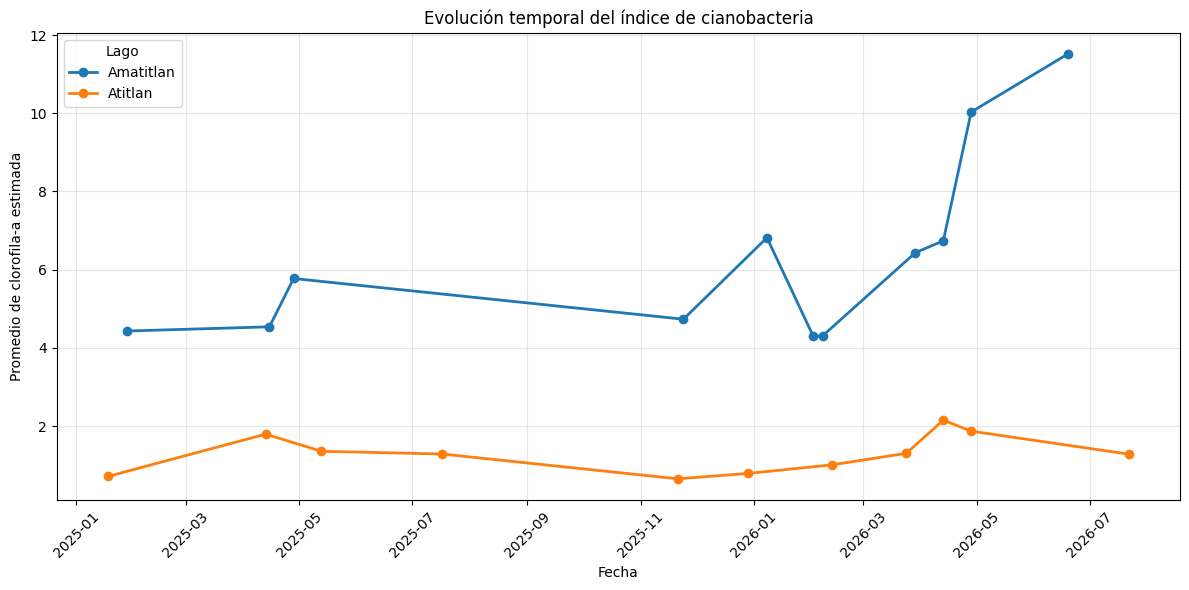

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for lago, grupo in df_resultados.groupby("lago"):
    plt.plot(
        grupo["fecha"],
        grupo["promedio_cyano"],
        marker="o",
        linewidth=2,
        label=lago.capitalize()
    )

plt.title("Evolución temporal del índice de cianobacteria")
plt.xlabel("Fecha")
plt.ylabel("Promedio de clorofila-a estimada")
plt.legend(title="Lago")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

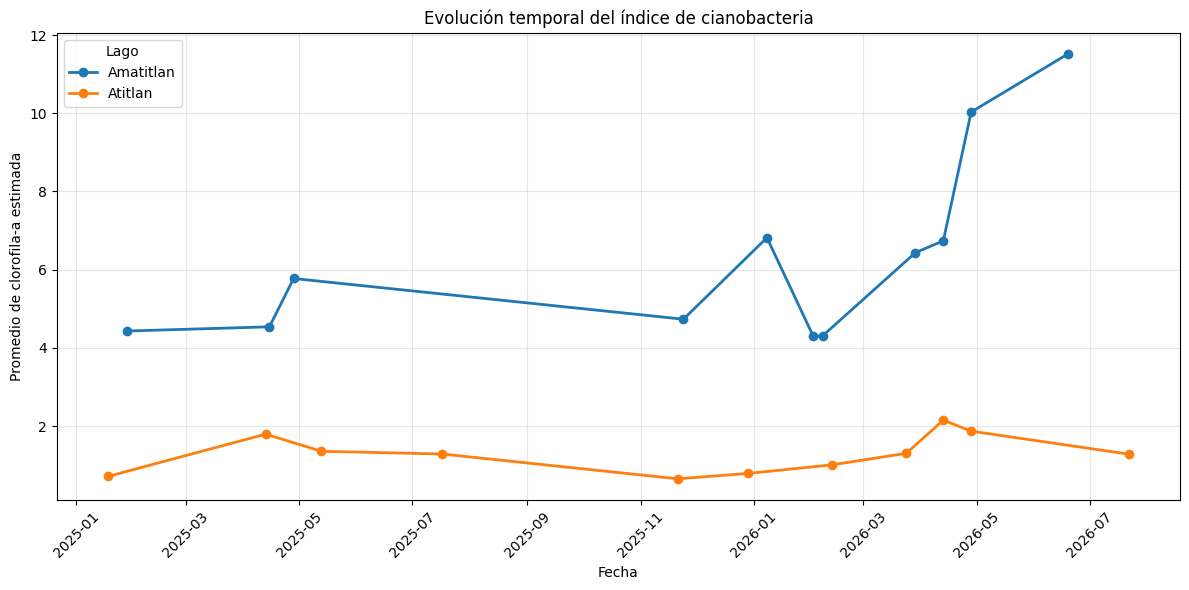

In [52]:
plt.figure(figsize=(12, 6))

for lago, grupo in df_resultados.groupby("lago"):
    plt.plot(
        grupo["fecha"],
        grupo["promedio_cyano"],
        marker="o",
        linewidth=2,
        label=lago.capitalize()
    )

plt.title("Evolución temporal del índice de cianobacteria")
plt.xlabel("Fecha")
plt.ylabel("Promedio de clorofila-a estimada")
plt.legend(title="Lago")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "evolucion_temporal_cianobacteria.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Picos

In [53]:
picos = (
    df_resultados
    .sort_values(
        ["lago", "promedio_cyano"],
        ascending=[True, False]
    )
    .groupby("lago")
    .head(3)
)

picos[
    ["lago", "fecha", "promedio_cyano"]
]

,lago,fecha,promedio_cyano
10,amatitlan,2026-06-19,11.513505
9,amatitlan,2026-04-28,10.030859
4,amatitlan,2026-01-08,6.816948
19,atitlan,2026-04-13,2.150134
20,atitlan,2026-04-28,1.868356
12,atitlan,2025-04-13,1.791907


Maximos picos

In [54]:
indices_maximos = df_resultados.groupby("lago")[
    "promedio_cyano"
].idxmax()

maximos = df_resultados.loc[
    indices_maximos,
    ["lago", "fecha", "promedio_cyano"]
]

maximos

,lago,fecha,promedio_cyano
10,amatitlan,2026-06-19,11.513505
19,atitlan,2026-04-13,2.150134


Lago atitlan

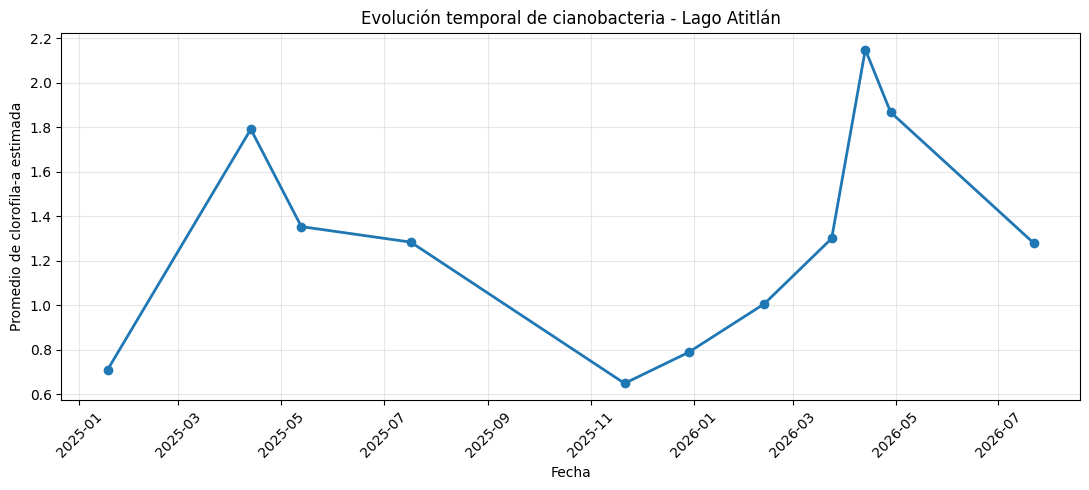

In [55]:
atitlan_plot = df_resultados[
    df_resultados["lago"] == "atitlan"
]

plt.figure(figsize=(11, 5))

plt.plot(
    atitlan_plot["fecha"],
    atitlan_plot["promedio_cyano"],
    marker="o",
    linewidth=2
)

plt.title("Evolución temporal de cianobacteria - Lago Atitlán")
plt.xlabel("Fecha")
plt.ylabel("Promedio de clorofila-a estimada")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "temporal_atitlan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Lago amatitlan

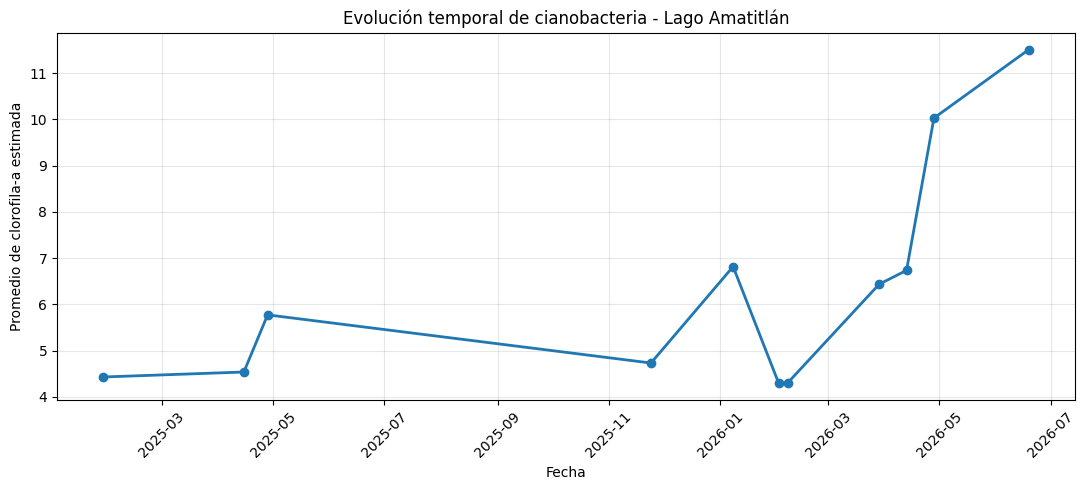

In [56]:
amatitlan_plot = df_resultados[
    df_resultados["lago"] == "amatitlan"
]

plt.figure(figsize=(11, 5))

plt.plot(
    amatitlan_plot["fecha"],
    amatitlan_plot["promedio_cyano"],
    marker="o",
    linewidth=2
)

plt.title("Evolución temporal de cianobacteria - Lago Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Promedio de clorofila-a estimada")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(
    "temporal_amatitlan.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Análisis temporal de cianobacteria

### 4.1 Índice promedio por lago y fecha

Se calculó para cada fecha el valor promedio de clorofila-a estimada mediante
el índice de cianobacteria, considerando únicamente los píxeles identificados
como agua. Los valores negativos producidos por el modelo fueron truncados a
cero, ya que no representan concentraciones físicamente interpretables.

### 4.2 Evolución temporal

Los resultados muestran diferencias claras entre ambos lagos. El lago Atitlán
presenta valores promedio relativamente bajos y con fluctuaciones moderadas a
lo largo del período estudiado. En cambio, el lago Amatitlán presenta valores
considerablemente mayores y una variación temporal más pronunciada.

### 4.3 Picos y fechas críticas

Para el lago Atitlán, el mayor valor promedio se observó el 13 de abril de
2026, con un valor aproximado de 2.1501. Otros valores elevados ocurrieron el
28 de abril de 2026 (1.8684) y el 13 de abril de 2025 (1.7919).

Para el lago Amatitlán, el mayor valor promedio se registró el 19 de junio de
2026, con aproximadamente 11.5135. También se identificaron valores elevados
el 28 de abril de 2026 (10.0309) y el 8 de enero de 2026 (6.8169).

Por lo tanto, estas fechas pueden considerarse fechas críticas dentro del
período analizado.

### 4.4 Interpretación de los patrones temporales

En Atitlán, la proliferación estimada fluctúa durante el período analizado,
pero los cambios son relativamente moderados. Es notable que los tres valores
promedio más altos se encuentran en abril, tanto en 2025 como en 2026, lo que
sugiere que podría existir un comportamiento temporal recurrente durante este
mes. Sin embargo, con las fechas disponibles no es suficiente para establecer
un patrón estacional definitivo.

Amatitlán muestra un comportamiento diferente. Los valores alcanzan
magnitudes considerablemente mayores, especialmente durante 2026. Se observa
un valor elevado en enero de 2026 y posteriormente picos aún mayores en abril
y junio de 2026. Esto indica un incremento importante de la señal asociada con
cianobacteria durante parte de 2026, aunque existen fluctuaciones entre las
fechas analizadas.

Las variaciones observadas podrían estar relacionadas con factores ambientales
como temperatura, disponibilidad de nutrientes, precipitación, escorrentía y
condiciones de mezcla o estancamiento del agua. Sin embargo, estos factores no
fueron medidos directamente en este análisis, por lo que no es posible atribuir
los cambios observados a una causa específica únicamente con las imágenes
satelitales utilizadas.